In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg

conn = psycopg.connect("dbname=sound_retention")

In [5]:
conn.close()
conn = psycopg.connect("dbname=sound_retention")

In [6]:
query = """
WITH listening_summary AS (
    SELECT
        user_key,
        COUNT(*) AS listening_days,
        SUM(total_secs) AS total_listening_secs,
        SUM(num_unq) AS total_unique_songs
    FROM analytics.fact_listening
    GROUP BY user_key
),

subscription_summary AS (
    SELECT
        user_key,
        COUNT(*) AS transaction_count,
        SUM(actual_amount_paid) AS total_amount_paid,
        AVG(actual_amount_paid) AS avg_amount_paid,
        SUM(payment_plan_days) AS total_plan_days,
        COUNT(*) FILTER (
            WHERE is_auto_renew = TRUE
        ) AS auto_renew_transactions,
        COUNT(*) FILTER (
            WHERE is_cancel = TRUE
        ) AS cancelled_transactions
    FROM analytics.fact_subscription
    GROUP BY user_key
)

SELECT
    u.user_key,
    c.is_churn,
    u.gender,
    u.registered_via,
    u.city,

    COALESCE(l.listening_days, 0) AS listening_days,
    COALESCE(l.total_listening_secs, 0) AS total_listening_secs,
    COALESCE(l.total_unique_songs, 0) AS total_unique_songs,

    COALESCE(s.transaction_count, 0) AS transaction_count,
    COALESCE(s.total_amount_paid, 0) AS total_amount_paid,
    s.avg_amount_paid,
    COALESCE(s.total_plan_days, 0) AS total_plan_days,
    COALESCE(s.auto_renew_transactions, 0) AS auto_renew_transactions,
    COALESCE(s.cancelled_transactions, 0) AS cancelled_transactions

FROM analytics.fact_churn c

JOIN analytics.dim_user u
    ON c.user_key = u.user_key

LEFT JOIN listening_summary l
    ON u.user_key = l.user_key

LEFT JOIN subscription_summary s
    ON u.user_key = s.user_key
"""

users = pd.read_sql(query, conn)

print(users.shape)
users.head()

/tmp/ipykernel_24548/1437725111.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql(query, conn)


(970960, 14)


,user_key,is_churn,gender,registered_via,city,listening_days,total_listening_secs,total_unique_songs,transaction_count,total_amount_paid,avg_amount_paid,total_plan_days,auto_renew_transactions,cancelled_transactions
0,37,True,female,3.0,15.0,27,461992.316,1463,3,1200,400.0,420,0,0
1,10096,False,NaN,7.0,1.0,12,34967.632,92,1,149,149.0,30,1,0
2,10434,False,male,9.0,13.0,31,361887.092,1497,1,149,149.0,30,1,0
3,10557,False,male,7.0,5.0,6,44222.741,172,1,149,149.0,30,1,0
4,10591,False,male,7.0,10.0,21,71990.346,218,1,99,99.0,30,1,0


is_churn
Retained    883630
Churned      87330
Name: count, dtype: int64

Percentage:
is_churn
Retained    91.01
Churned      8.99
Name: count, dtype: float64


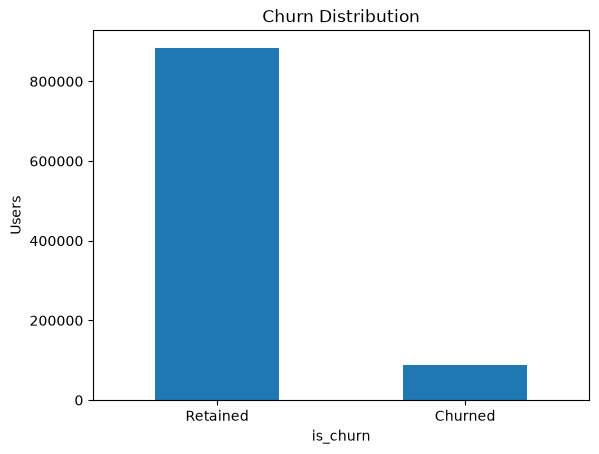

In [7]:
churn = (
    users["is_churn"]
    .value_counts()
    .rename(index={False: "Retained", True: "Churned"})
)

print(churn)
print("\nPercentage:")
print((churn / len(users) * 100).round(2))

churn.plot(kind="bar", title="Churn Distribution")
plt.ylabel("Users")
plt.xticks(rotation=0)
plt.show()

gender
Missing    582055
male       204561
female     184344
Name: count, dtype: int64

Percentage:
gender
Missing    59.95
male       21.07
female     18.99
Name: count, dtype: float64


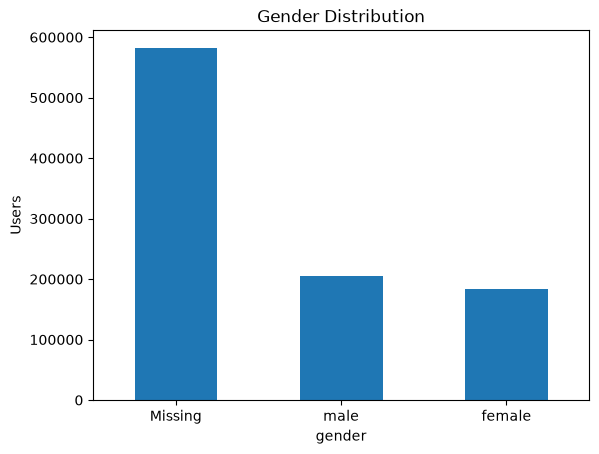

In [8]:
gender = (
    users["gender"]
    .fillna("Missing")
    .value_counts()
)

print(gender)
print("\nPercentage:")
print((gender / len(users) * 100).round(2))

gender.plot(kind="bar", title="Gender Distribution")
plt.ylabel("Users")
plt.xticks(rotation=0)
plt.show()

registered_via
7.0     462684
9.0     235689
3.0     106459
4.0      52744
13.0      3391
Name: count, dtype: int64


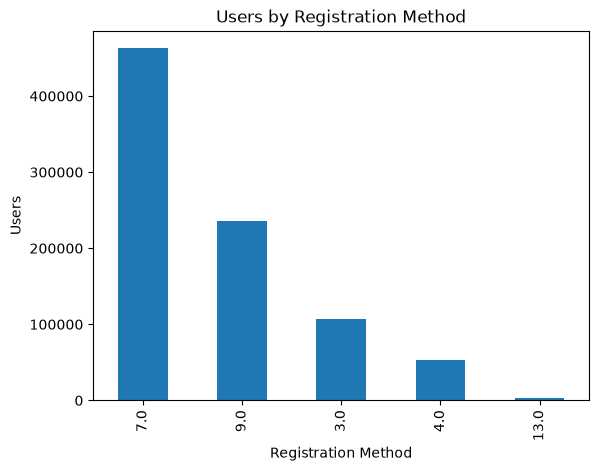

In [9]:
registration = users["registered_via"].value_counts().sort_values(ascending=False)

print(registration)

registration.plot(kind="bar", title="Users by Registration Method")
plt.ylabel("Users")
plt.xlabel("Registration Method")
plt.show()

city
1.0     442598
13.0     97136
5.0      70706
4.0      47227
15.0     43187
22.0     41991
6.0      26066
14.0     20013
12.0     11383
9.0       9526
Name: count, dtype: int64


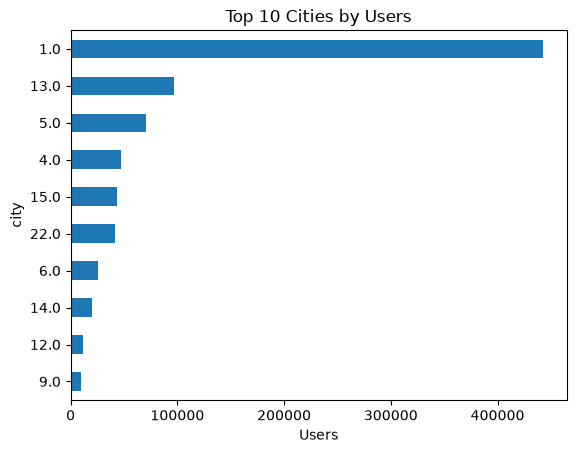

In [10]:
city = users["city"].value_counts().head(10)

print(city)

city.sort_values().plot(kind="barh", title="Top 10 Cities by Users")
plt.xlabel("Users")
plt.show()

In [11]:
listening_cols = [
    "listening_days",
    "total_listening_secs",
    "total_unique_songs"
]

print(
    users[listening_cols]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

                         count           mean            std  min        50%  \
listening_days        970960.0      13.937695      11.335191  0.0     14.000   
total_listening_secs  970960.0  108629.052776  173586.213729  0.0  49982.129   
total_unique_songs    970960.0     397.790601     565.908699  0.0    202.000   

                              75%          90%          95%           99%  \
listening_days            25.0000      30.0000      31.0000      31.00000   
total_listening_secs  140794.6155  278405.6036  413659.2464  850075.37192   
total_unique_songs       552.0000    1038.0000    1459.0000    2686.00000   

                               max  
listening_days        3.100000e+01  
total_listening_secs  1.433739e+07  
total_unique_songs    2.340300e+04  


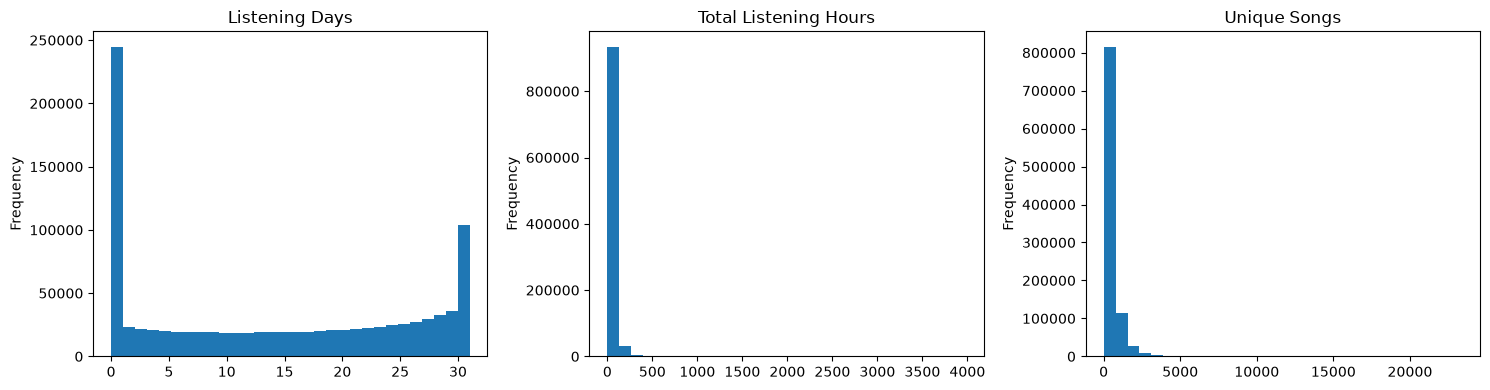

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

users["listening_days"].plot(
    kind="hist", bins=30, ax=axes[0],
    title="Listening Days"
)

(users["total_listening_secs"] / 3600).plot(
    kind="hist", bins=30, ax=axes[1],
    title="Total Listening Hours"
)

users["total_unique_songs"].plot(
    kind="hist", bins=30, ax=axes[2],
    title="Unique Songs"
)

plt.tight_layout()
plt.show()

In [13]:
print("Listening days:")
print(users["listening_days"].quantile([0, .5, .95, .99, 1]))

print("\nListening hours:")
print((users["total_listening_secs"] / 3600).quantile([0, .5, .95, .99, 1]))

print("\nUnique songs:")
print(users["total_unique_songs"].quantile([0, .5, .95, .99, 1]))

Listening days:
0.00     0.0
0.50    14.0
0.95    31.0
0.99    31.0
1.00    31.0
Name: listening_days, dtype: float64

Listening hours:
0.00       0.000000
0.50      13.883925
0.95     114.905346
0.99     236.132048
1.00    3982.608713
Name: total_listening_secs, dtype: float64

Unique songs:
0.00        0.0
0.50      202.0
0.95     1459.0
0.99     2686.0
1.00    23403.0
Name: total_unique_songs, dtype: float64


In [14]:
subscription_cols = [
    "transaction_count",
    "total_amount_paid",
    "avg_amount_paid",
    "total_plan_days",
    "auto_renew_transactions",
    "cancelled_transactions"
]

print(
    users[subscription_cols]
    .describe(percentiles=[.50, .75, .90, .95, .99])
    .T
)

                            count        mean         std  min    50%    75%  \
transaction_count        970960.0    1.165894    1.282383  0.0    1.0    1.0   
total_amount_paid        970960.0  169.082417  229.840991  0.0  149.0  149.0   
avg_amount_paid          933578.0  143.761684  133.723976  0.0  149.0  149.0   
total_plan_days          970960.0   39.127741   52.254150  0.0   30.0   30.0   
auto_renew_transactions  970960.0    1.068310    1.223313  0.0    1.0    1.0   
cancelled_transactions   970960.0    0.033866    0.184404  0.0    0.0    0.0   

                           90%    95%     99%      max  
transaction_count          2.0    2.0     3.0    208.0  
total_amount_paid        298.0  298.0  1200.0  13650.0  
avg_amount_paid          180.0  180.0   600.0   2000.0  
total_plan_days           60.0   60.0   330.0   2080.0  
auto_renew_transactions    2.0    2.0     3.0     65.0  
cancelled_transactions     0.0    0.0     1.0      8.0  


In [15]:
print("Auto-renew transactions:")
print(users["auto_renew_transactions"].value_counts().sort_index())

print("\nCancelled transactions:")
print(users["cancelled_transactions"].value_counts().sort_index())

Auto-renew transactions:
auto_renew_transactions
0     118159
1     744741
2      92735
3       7063
4       1529
5       1469
6        751
7        554
8        408
9        319
10       275
11       343
12       272
13       275
14       253
15       206
16       151
17       116
18        60
19       112
20       154
21       272
22       104
23        81
24        43
25        53
26        36
27        37
28        43
29        38
30        26
31        29
32        31
33        30
34        29
35        40
36        44
37        37
38        15
39         7
40         2
41         2
43         1
44         1
45         5
46         2
47         1
48         3
49         1
61         1
65         1
Name: count, dtype: int64

Cancelled transactions:
cancelled_transactions
0    938635
1     31807
2       491
3        21
4         2
5         3
8         1
Name: count, dtype: int64


In [16]:
users["engagement_band"] = pd.cut(
    users["listening_days"],
    bins=[-1, 0, 7, 14, 31],
    labels=["No listening", "Low", "Medium", "High"]
)

engagement = (
    users.groupby("engagement_band", observed=False)
    .agg(
        users=("user_key", "count"),
        churned_users=("is_churn", "sum")
    )
)

engagement["churn_rate_pct"] = (
    engagement["churned_users"] / engagement["users"] * 100
).round(2)

engagement

,users,churned_users,churn_rate_pct
engagement_band,,,
No listening,216409,19690,9.10
Low,153219,18953,12.37
Medium,133490,12992,9.73
High,467842,35695,7.63


## EDA Conclusions

### Gender
65.43% of member records have missing gender. Missing values are retained
rather than imputed because there is no defensible basis for assigning a
gender.

### Birth year / age field (`bd`)
The field contains substantial suspicious values, including negative
values and a very large number of zeros. It is therefore excluded from
current analytical use rather than being corrected using an arbitrary
rule.

### Listening activity
Listening activity varies substantially across users. Extreme values
are retained because high activity is not itself evidence of invalid
data. Aggregation and distribution-aware analysis are used instead.

### Subscription data
Transaction amounts, plan durations, and transaction counts vary across
users. No negative payment, plan-duration, or listening metrics were
identified, so valid values are retained.

### Overall
The EDA confirms that the cleaned analytical data is suitable for the
planned churn analysis while documenting fields that should not be
treated as reliable without further assumptions.